# Group Relative Policy Optimization

- DeepSeek explained: https://thelmbook.com/articles/#!./DeepSeek-R1.md
- https://www.youtube.com/watch?v=Yi1UCrAsf4o&t=1156s

# Basic RL (PPO)

States: where the agent cant be

Actions: choice from a certain state

Values: Rewards and Loss that the agent can reach from the initial position. Each Action may 'cost'. The maximum reward a certain state can reach

Policy: every choice defined based on the state

Value Network: Impossible to reach every single "state" in reality. So we get the "value" approximation

Policy Network: Impossible to try every single policy. Get policy of certain state.

The objective(loss) function for policy neural network:

$$L_{policy}(\theta) = \mathbb{E} \frac{\pi_{\theta} (a_t|s_t)}{\pi_{\theta old}(a_t|s_t)} A_t $$

$$L^{CLIP}_{policy}(\theta) = \mathbb{E} \left[\min\left( \frac{\pi_{\theta}(a_t|s_t)}{\pi_{\theta old} (a_t|s_t)} \right)A_t, clip(\rho,1-\epsilon,1+\epsilon)A_t \right]$$

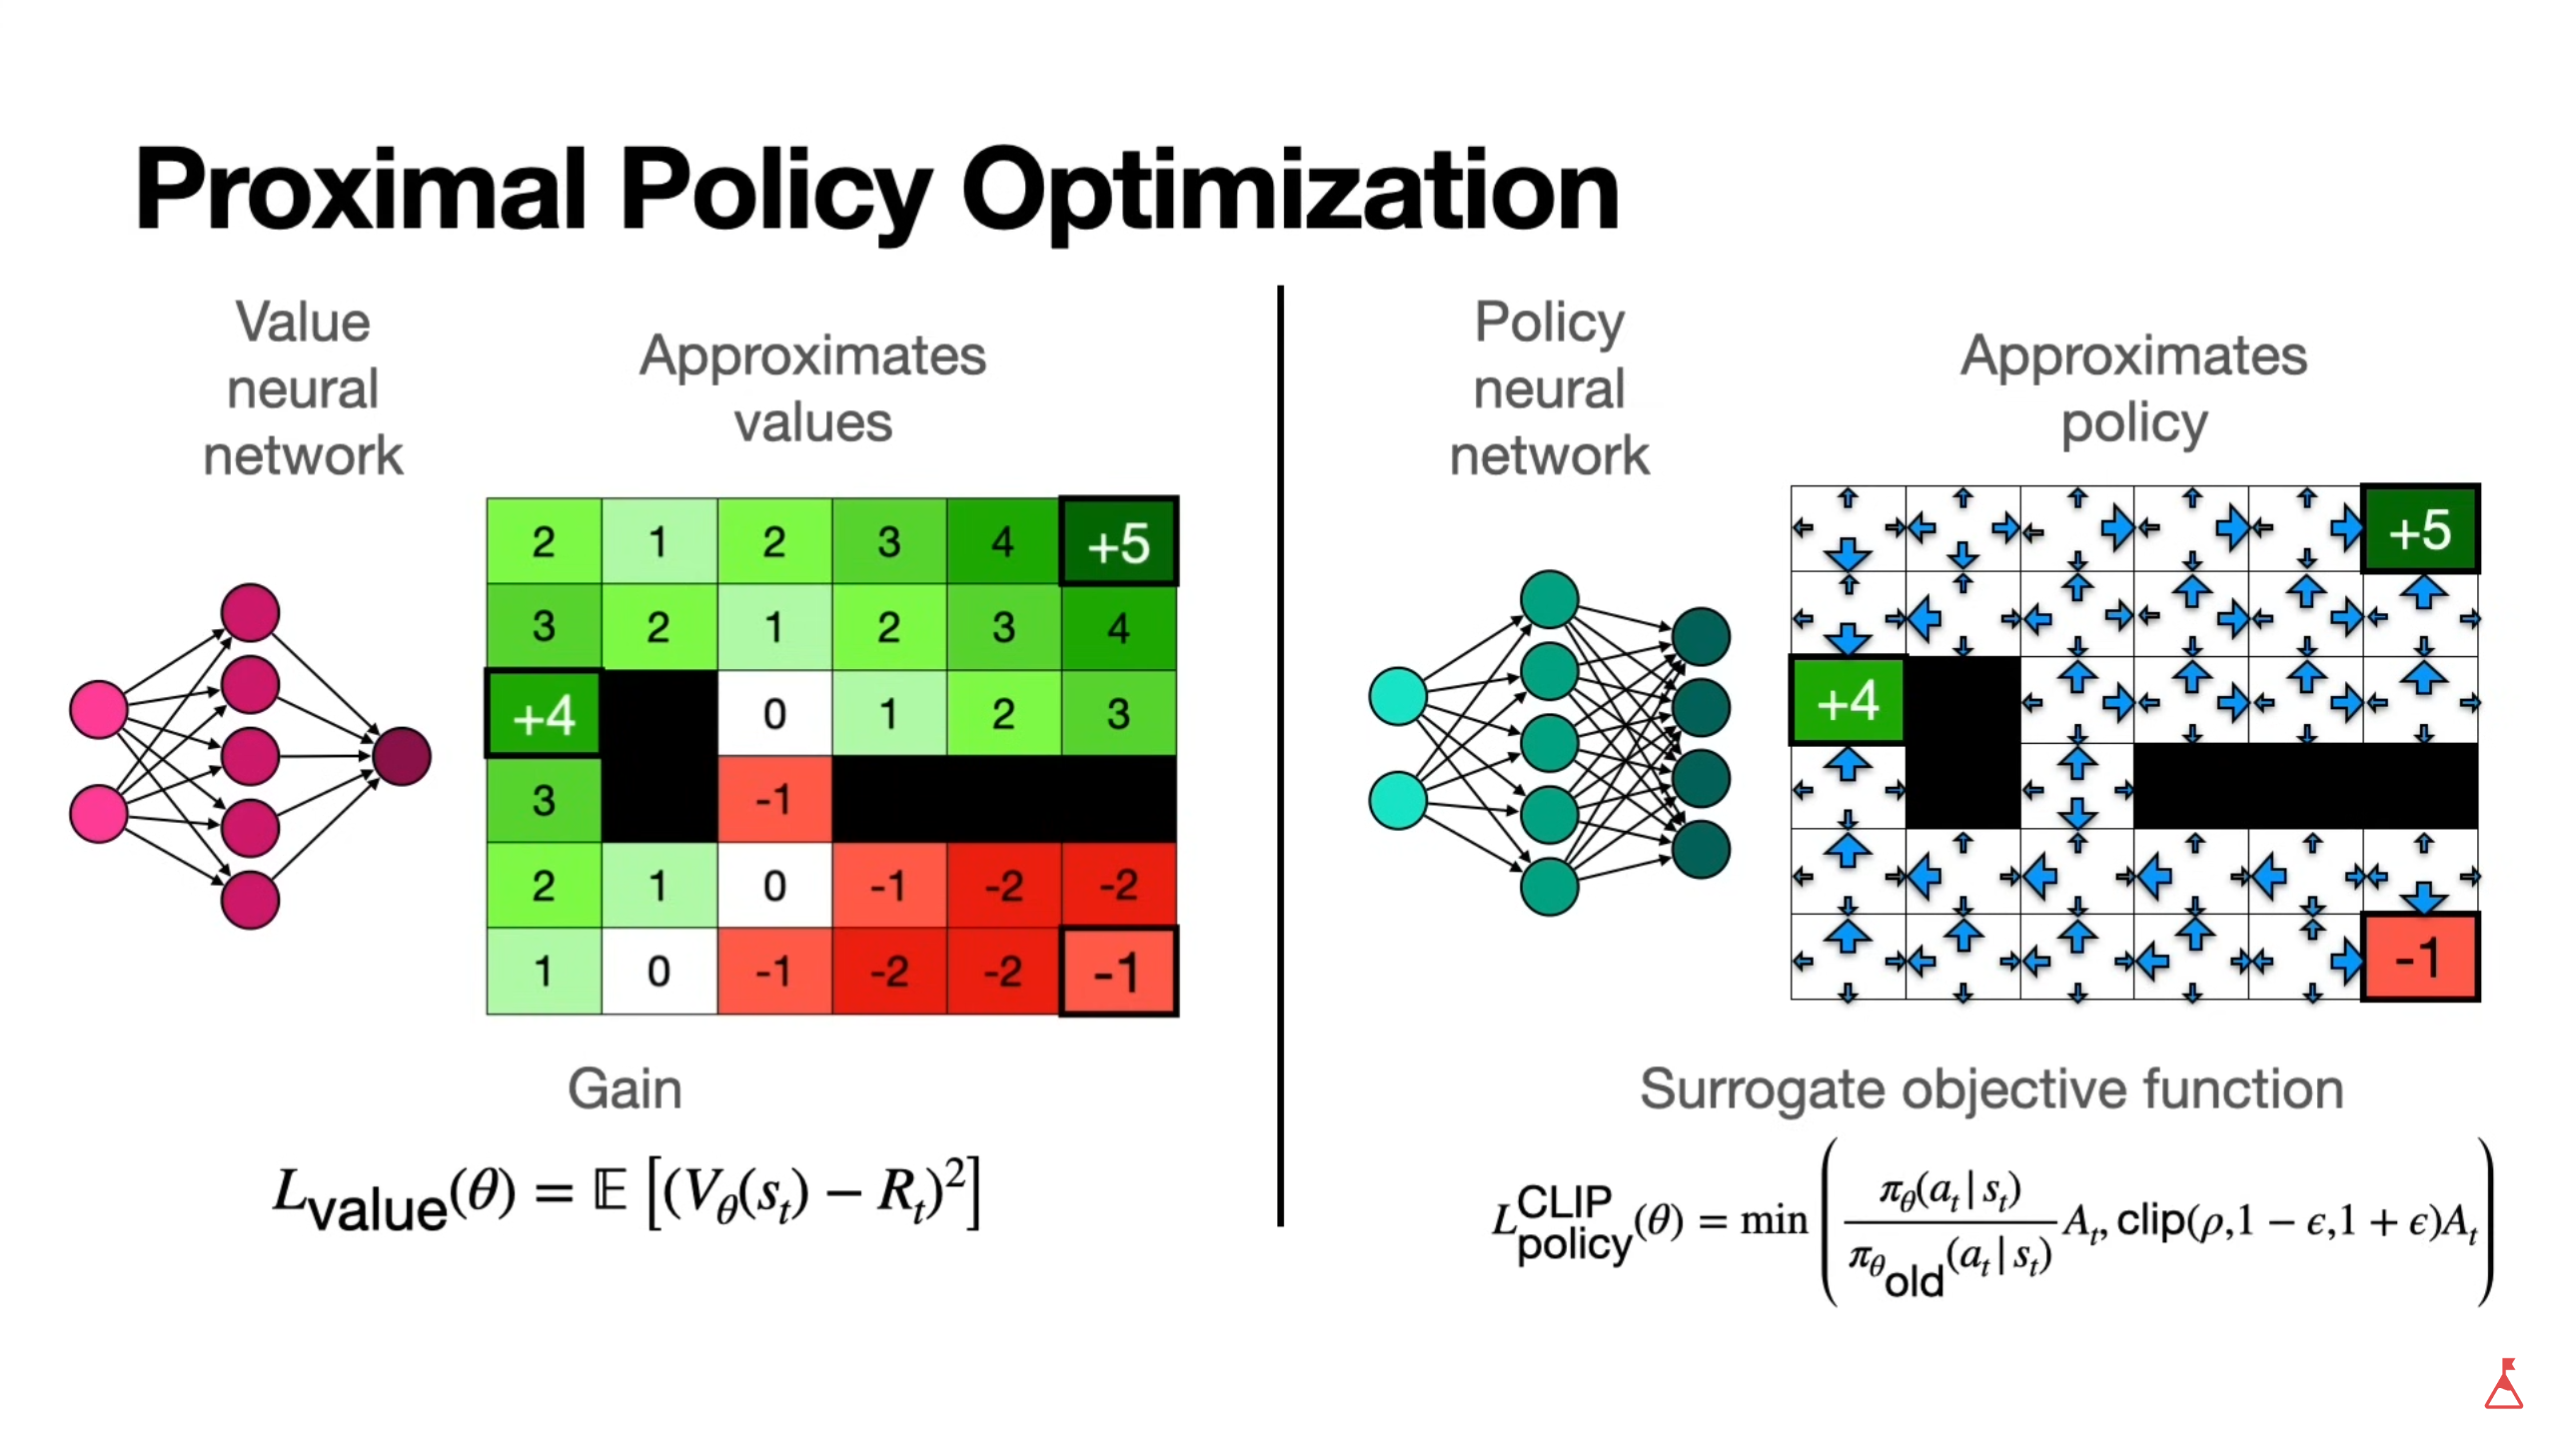

Actor-Critique method -> Policy function concurrent & Value function optimization

# PPO vs GRPO
- GRPO replaces the PPO value model to normalized reward
- removed the need of value model, focuses on the policy model



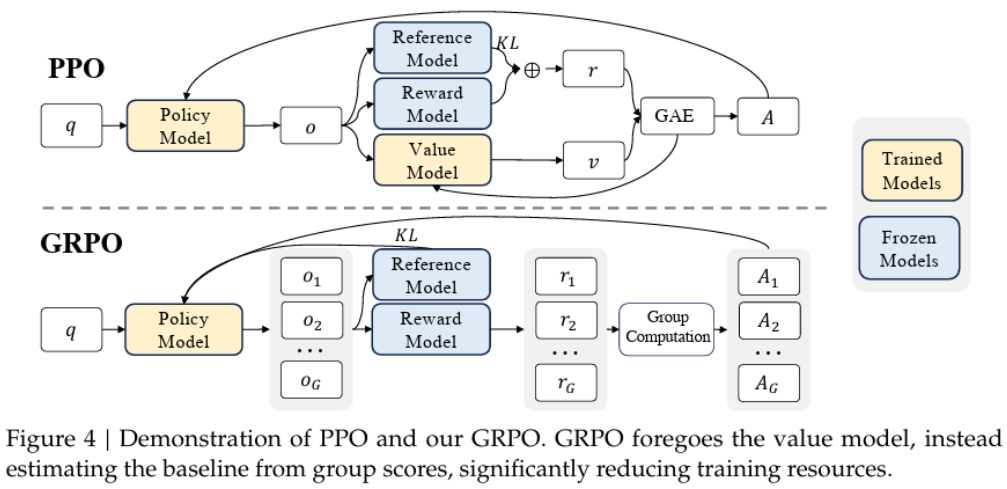

## Detailed Equation for LLM

- PPO)

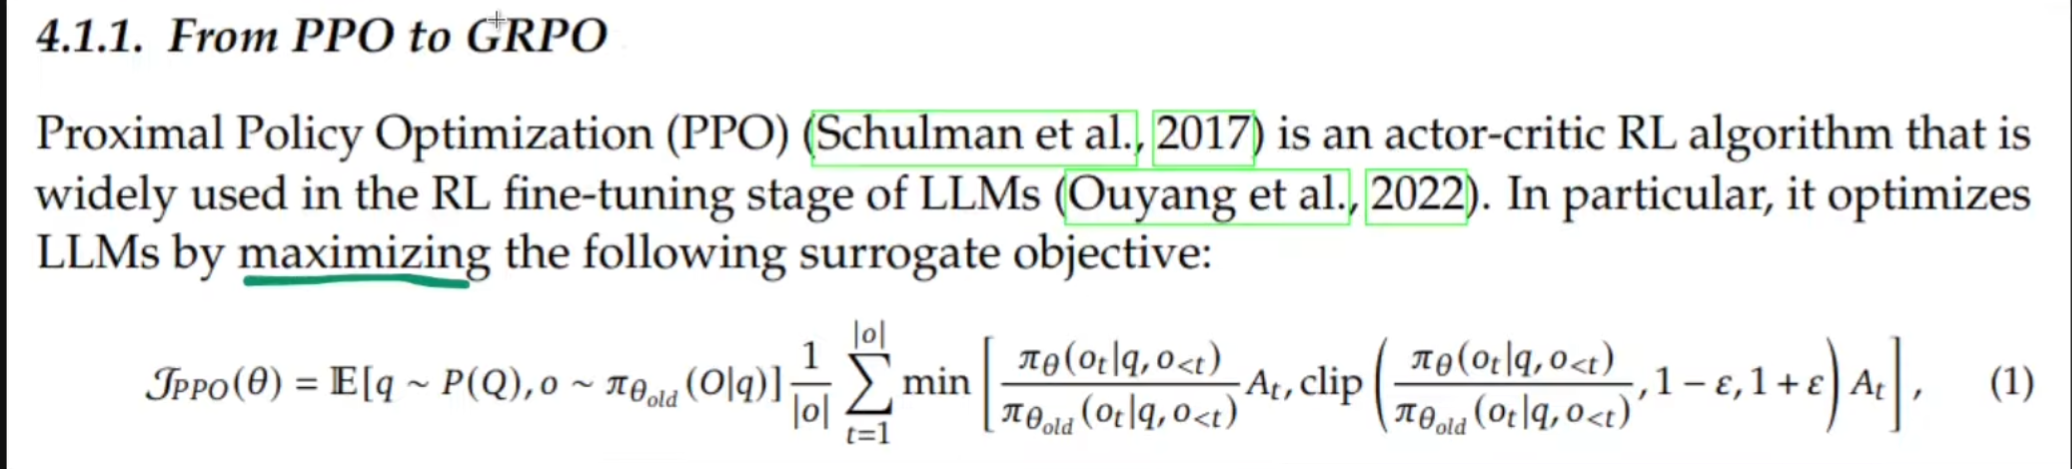

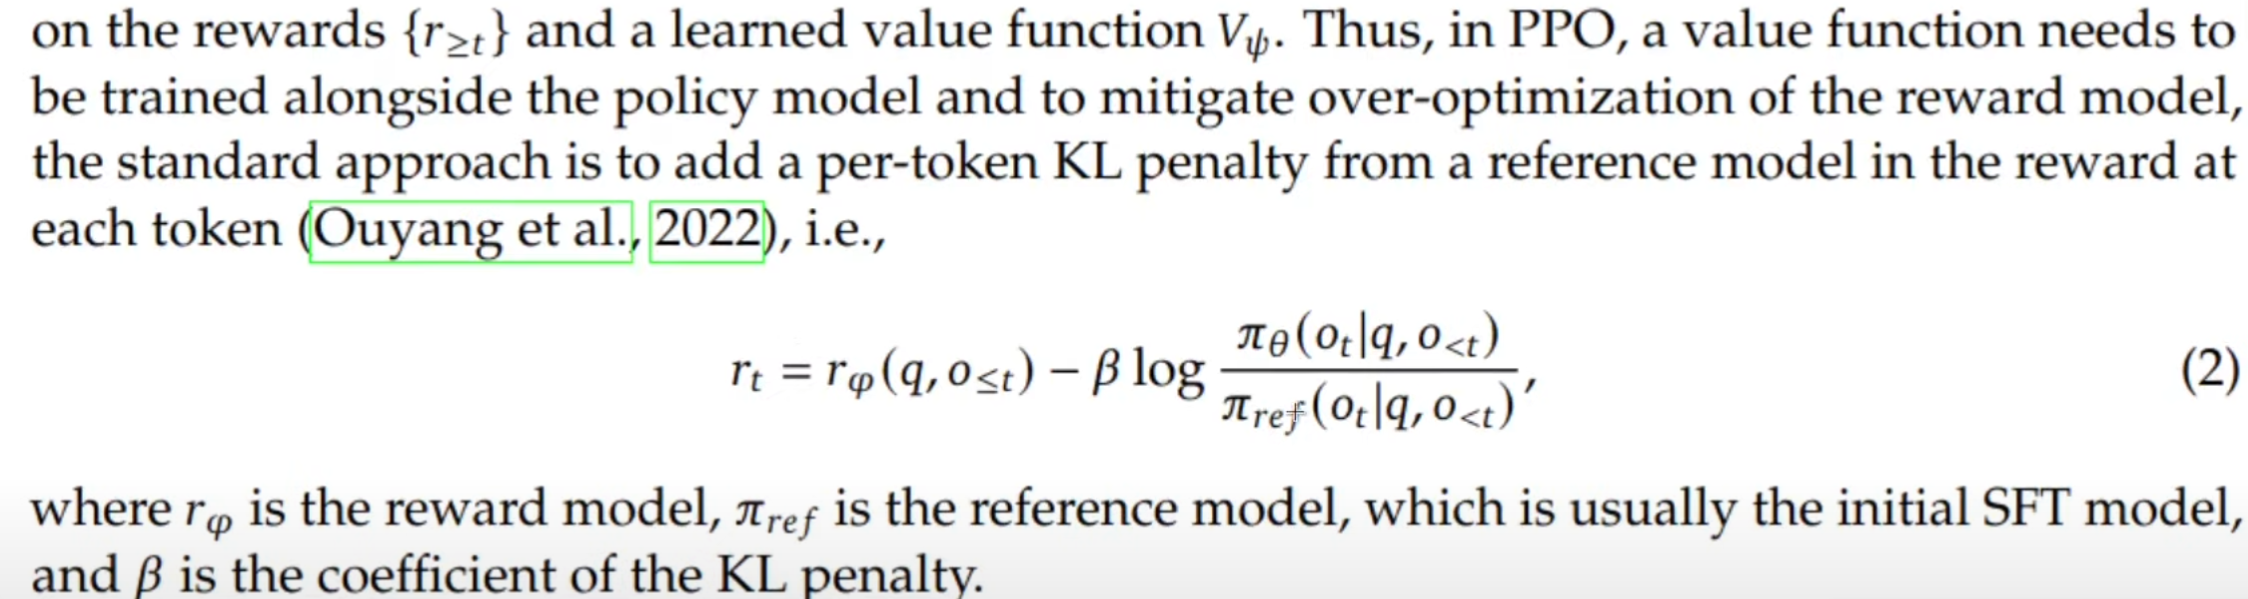

- GRPO)

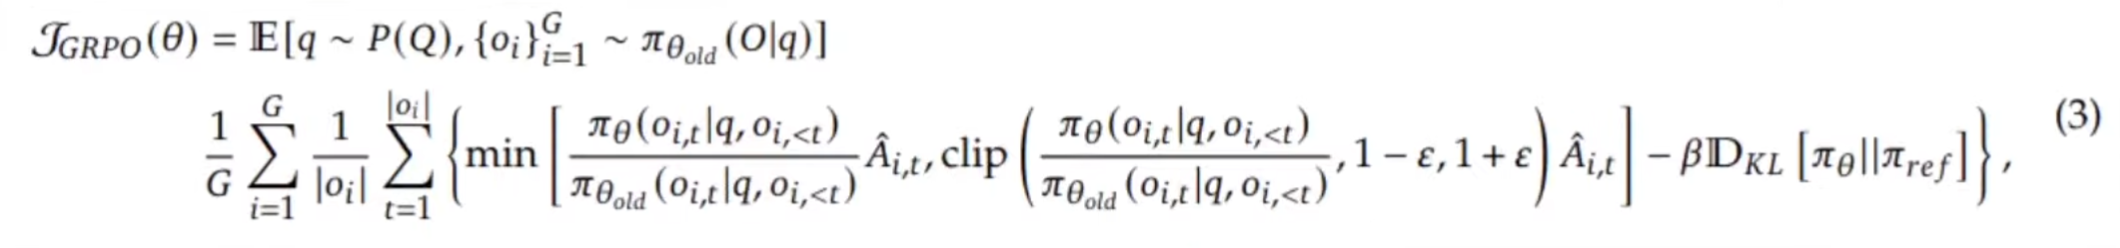

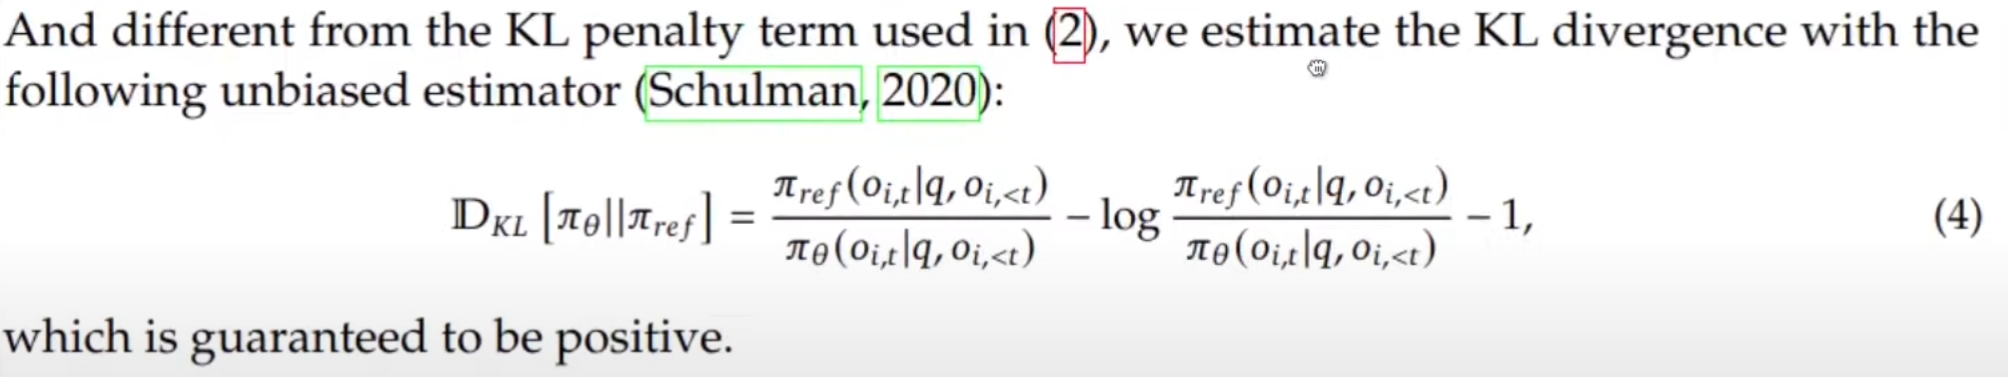

## 1. Different Advantage Function

- PPO Advantage Function (surrogate):

$$A = f(r)$$

- GRPO Advantage Function (surrogate):

$$A = \frac{r - \mu}{\sigma}$$


## 2. Compare Multiple Outputs at once

- PPO: one output per question

- GRPO: "group of outputs" (G) on the question evaluated at once


## 3. KL penalty


$$\mathbb{D}_{KL}(\pi_{theta}||\pi_{ref}) = \frac{\pi_{ref}(o_i|q)}{\pi_{theta}(o_i|q)} - log\frac{\pi_{ref}(o_i|q)}{\pi_{theta}(o_i|q)} -1$$

Original Cross Entropy:

$$H(p,q) = \Sigma_{x \in \mathcal{X}} $$


- PPO: KL penalty is applied "per token", the reward log function above compares the two distributions

- GRPO: removes the KL penalty from the reward function and directly applies it to the policy optimization



## GRPO Process Visualized



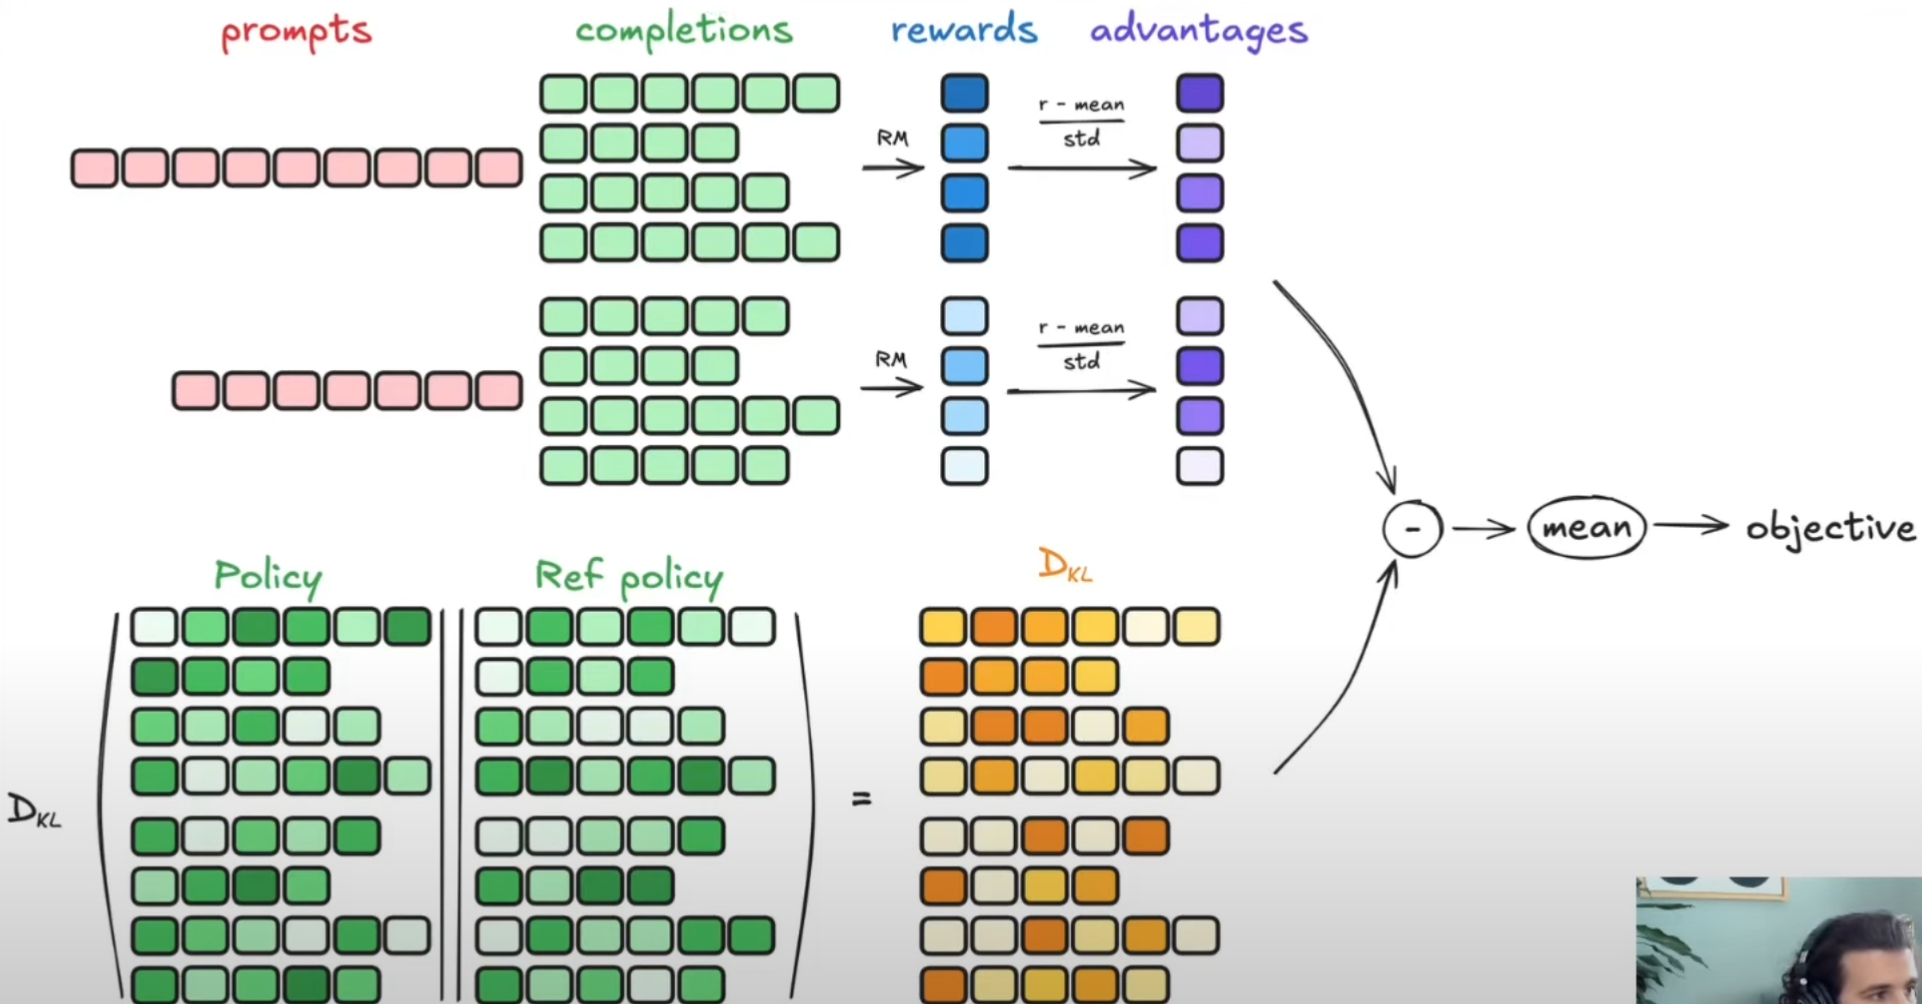

## GRPO Pseudo-Code

- $\pi_{ref}$ 라는 비교 기준? 이 되는 policy를 설정해둔다. Multiple steps before.

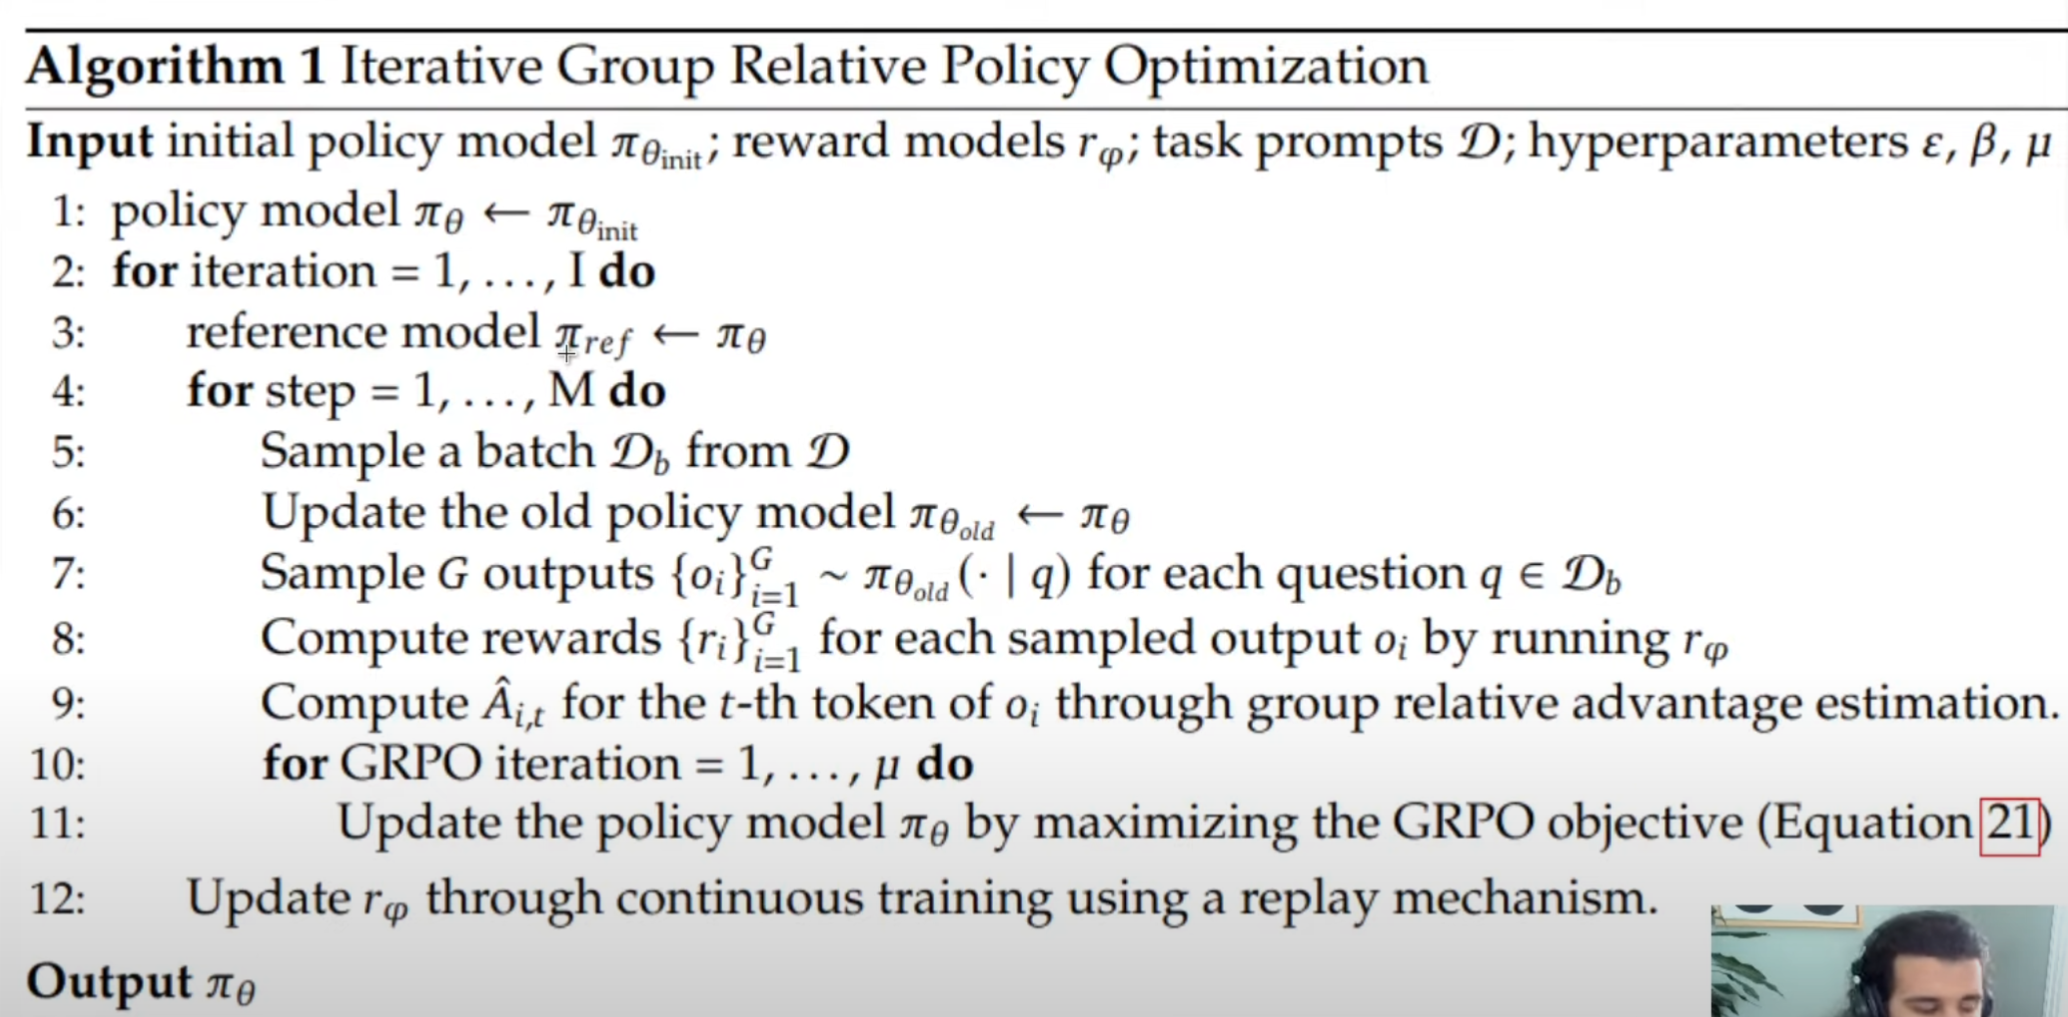

# GRPO Code Implementation

Overview)

link: https://huggingface.co/docs/trl/main/en/grpo_trainer

- "Loss" function so symbol negative
- "no grad" parameter will be the "old" policy
- omit clipping by fewer updates

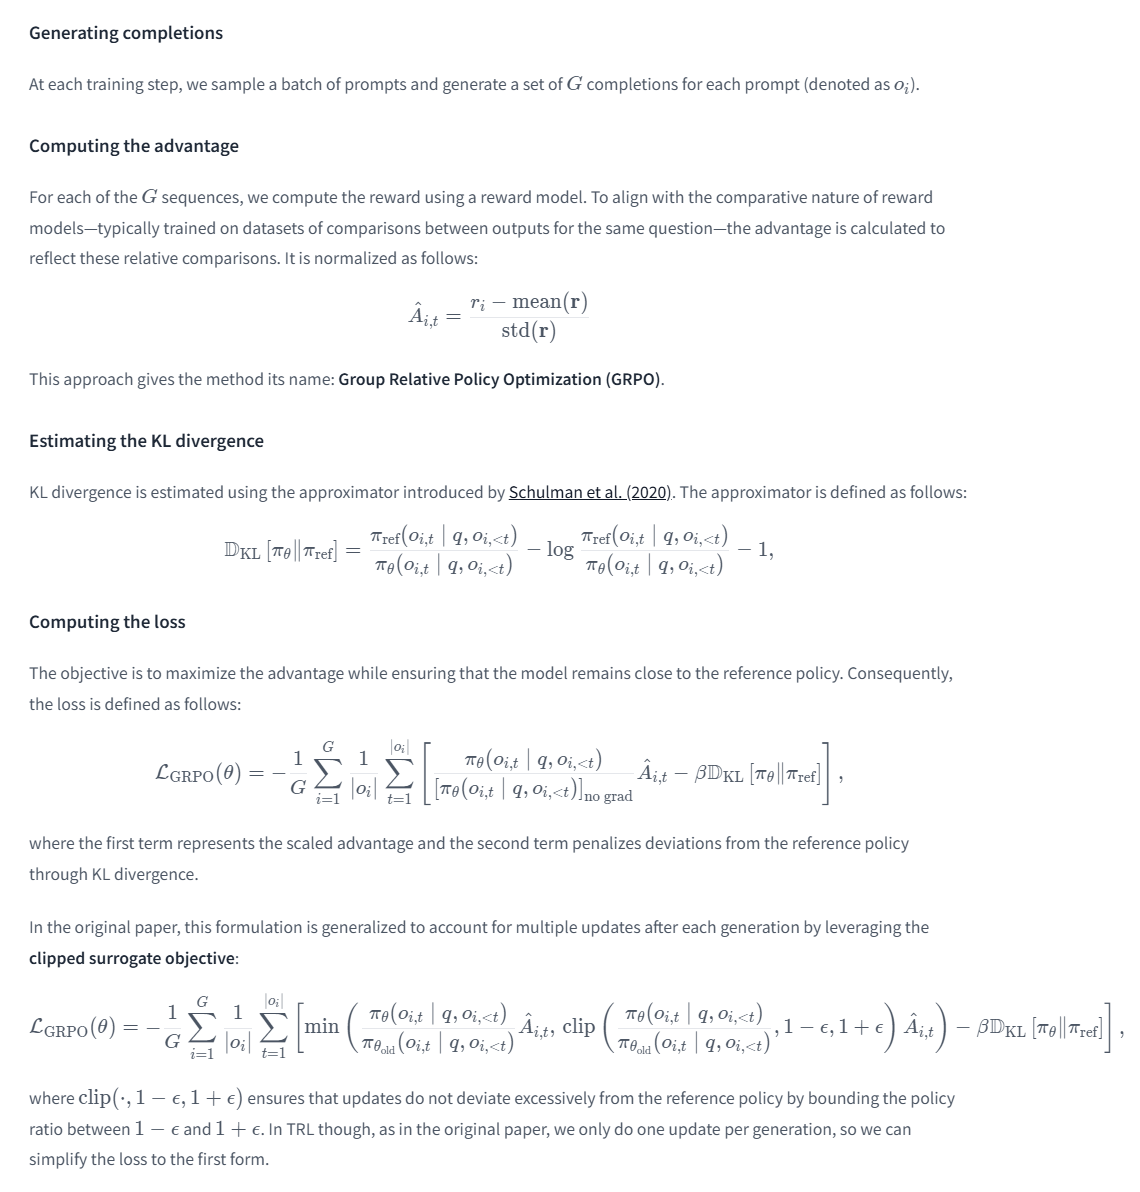

# Hugging Face LLM Training Code

In [ ]:
# save this as train_grpo.py

from datasets import load_datset
from trl import GRPOConfig, GRPOTrainer

dataset = load_dataset("trl-lib/tldr", split="train")

In [ ]:
# rewarding 20 characters
def reward_len(completions, **kwargs):
    return [-abs(20 - len(completion)) for completion in completions]

In [ ]:
training_args = GRPOConfig(output_dif="Qwen2-0.5B-GRPO", logging_steps=10)
trainer = GRPOTrainer(
    model="Qwen/Qwen2-0.5B-Instruct",
    reward_funcs=reward_len,
    args=training_args,
    train_dataset=dataset, # `use_vllm=True` for faster generation
)

trainer.train()

In [ ]:
# execute below script
# accelerate launch train_grpo.py

## Custom reward functions

1. Rewarding longer completions


Function)

```
def reward_func(completions, **kwargs):
    return [float(len(completion)) for completion in completions]
```

Test)
```
>>> prompts = ["the sky is", " the sun is"]
>>> completions = [" blue.", " in the sky."]
>>> print(reward_func())
```


2. Reward Specific format


Function)

```
import re

def format_reward_func(completions, **kwargs):
    pattern = r"^<think>.*?</think><answer>.*?</answer>$"
    completion_contents = [completion[0]["content] for completion in completions]
    return [1.0 if match else 0.0 for match in matches]
```

Test)
```
>>> prompts = [
    [{"role:": "assistant", "content": "What is the result of (1+2) * 4"}],
    [{"role": "assistant", "content": "What is the result of (3+1) * 2"}],
]
>>> completions = {
    [{"role": "assistant", "content": "<think>The sum of 1 and 2 is 3, which we multiply by 4 to get 12.</think><answer>(1 + 2) * 4 = 12</answer>"}],
    [{"role": "assistant", "content": "The sum of 3 and 1 is 4, which we multiply by 2 to get 8. So (3 + 1) * 2 = 8."}],
}
>>> format_reward_func(prompts=prompts, completions=completions)
[1.0, 0.0]
```

3. Reward completions based on reference (check only right and wrong)


Function)
```
import re

def reward_func(completions, ground_truth, **kwargs):
    matches = [re.search(r"\\boxed\{(.*?)\}", completion) for completion in completions]
    contents = [match.group(1) if match else "" for match in matches]
    return [1.0 if c == gt else 0.0 for c, gt in zip(contents, ground_truth)]
```

Test)
```
>>>prompts = ["Problem: Solve the equation $2x + 3 = 7$. Solution:", "Problem: Solve the equation $3x - 5 = 10$."]
>>>completions = [r" The solution is \boxed{2}.", r" The solution is \boxed{6}."]
ground_truth = ["2", "5"]
reward_func(prompts=prompts, completions=completions, ground_truth=ground_truth)
[1.0, 0.0]
```

multiple reward functions possible by passing them as list